In [1]:
from copy import deepcopy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

from src.data_analysis.significance_analysis import feature_importance_plot
from src.data_analysis.correlation_analysis import continuous_features_corr_plot, categorical_features_corr_plot
from src.modelling.model_evaluation import cross_validate_sklearn_model

In [2]:
data = load_diabetes(as_frame=True)
df = pd.concat([data['data'], data['target']], axis=1)

In [3]:
CATEGORICAL_FEATURES = ['sex']
NUMERICAL_FEATURES = ['age', 'bmi', 's1', 's2', 's3', 's4', 's5', 's6']
TARGET = 'target'

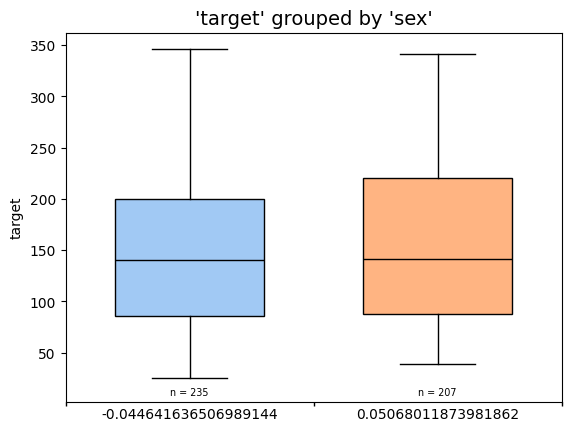

In [4]:
for feature in CATEGORICAL_FEATURES:
    feature_importance_plot(
        df=df, 
        feature=feature,
        target=TARGET,
        variable_type='categorical'
    )

In [5]:
# Simple categorical variables encoding
encoded_df = deepcopy(df)
label_encoders = {}
for feature in CATEGORICAL_FEATURES + [TARGET]:
    le = LabelEncoder()
    encoded_df[feature] = le.fit_transform(encoded_df[feature])
    label_encoders[feature] = le

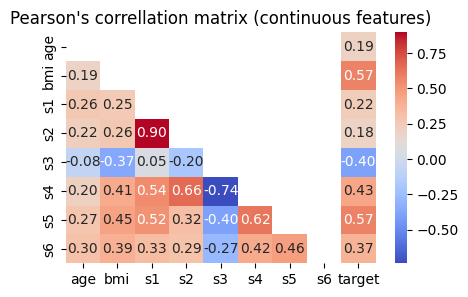

In [6]:
# Pearson's correllation for continuous variables
fig = continuous_features_corr_plot(df=encoded_df, features=NUMERICAL_FEATURES, target=TARGET)
plt.show()

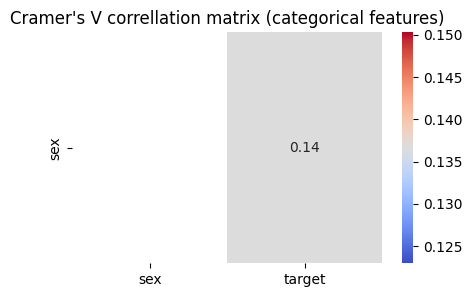

In [7]:
# Cramer's V correllation for continuous variables
fig = categorical_features_corr_plot(df=encoded_df, features=CATEGORICAL_FEATURES, target=TARGET)
plt.show()

In [8]:
model = GradientBoostingRegressor(n_estimators=300, subsample=0.3)

In [9]:
results = cross_validate_sklearn_model(
    model=model,
    inference_fn=model.predict,
    X=encoded_df.drop(TARGET, axis=1),
    Y=encoded_df[[TARGET]],
    n_folds=5,
    iterations=5,
    score_fns=[mean_absolute_error]
)

Cross validation:   0%|          | 0/5 [00:00<?, ?it/s]

Splits evaluation:   0%|          | 0/5 [00:00<?, ?it/s]

Splits evaluation:   0%|          | 0/5 [00:00<?, ?it/s]

Splits evaluation:   0%|          | 0/5 [00:00<?, ?it/s]

Splits evaluation:   0%|          | 0/5 [00:00<?, ?it/s]

Splits evaluation:   0%|          | 0/5 [00:00<?, ?it/s]

In [10]:
import numpy as np

print(f"MAE = {np.mean(results['mean_absolute_error']):.2f} ± {np.std(results['mean_absolute_error']):.2f}")

MAE = 39.81 ± 3.37
